# 📊 Data Storytelling & Statistical Validation

## Objective
To transform Adidas sales analysis into meaningful business insights and validate findings using statistical methods.

In [7]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

sns.set(style="whitegrid")

## 📌 Load Dataset

In [8]:
df = pd.read_csv("../data/adidas_sales.csv")

df.head()

,Unnamed: 0,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,NaN,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,600000.0,300000.0,0.50,in-store
1,NaN,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,500000.0,150000.0,0.30,in-store
2,NaN,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,400000.0,140000.0,0.35,in-store
3,NaN,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,382500.0,133875.0,0.35,in-store
4,NaN,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,540000.0,162000.0,0.30,in-store


# 📌 Business Storytelling

The Adidas sales dataset reveals important trends in product performance, regional contribution, and customer purchasing behavior.

The analysis focuses on:
- Sales growth
- Product demand
- Regional performance
- Profitability patterns
- Business opportunities


## 📌 Sales Performance Story

The analysis indicates that footwear products contribute the highest share of revenue.  
Regions such as the West and Northeast generate stronger sales performance compared to other regions.

Seasonal trends suggest increased customer demand during specific periods of the year.

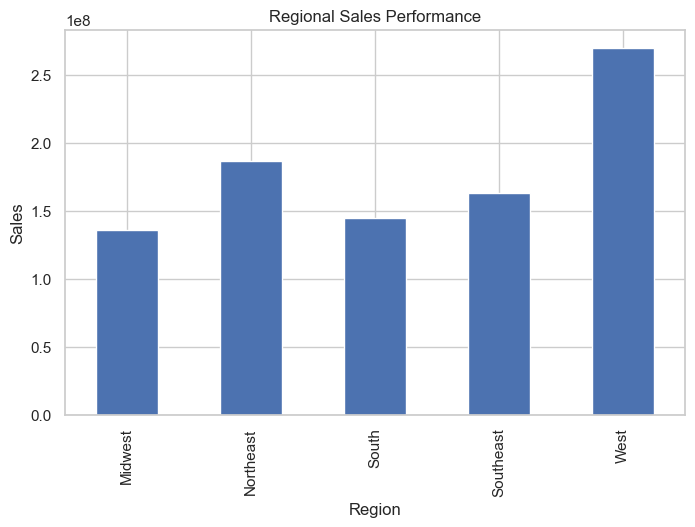

In [9]:
region_sales = df.groupby('Region')['Total Sales'].sum()

plt.figure(figsize=(8,5))

region_sales.plot(kind='bar')

plt.title("Regional Sales Performance")

plt.ylabel("Sales")

plt.show()

## 📌 Product Performance Story

Footwear products significantly outperform apparel categories in terms of total sales and profitability.

This indicates stronger customer preference toward Adidas footwear products.

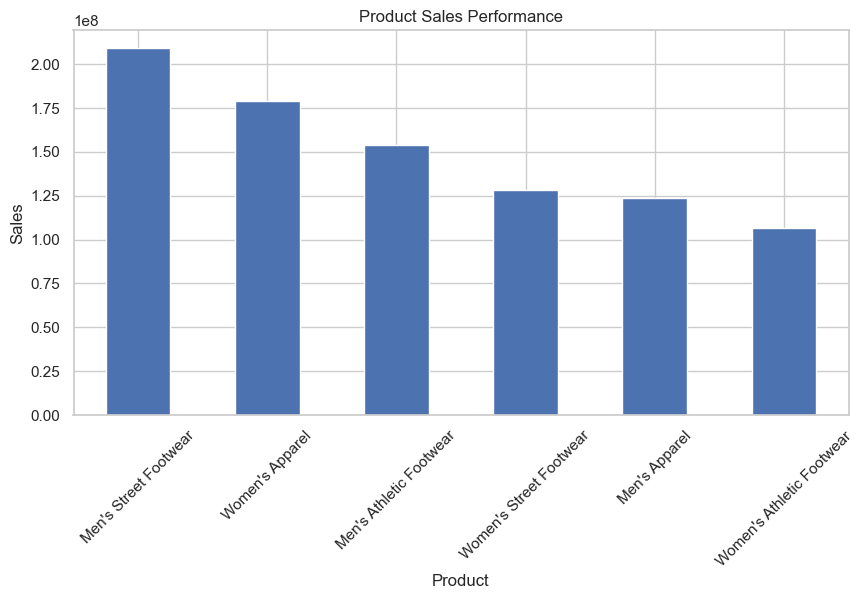

In [10]:
product_sales = df.groupby('Product')['Total Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

product_sales.plot(kind='bar')

plt.title("Product Sales Performance")

plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

# 📌 Hypothesis Testing

Hypothesis testing helps determine whether observed business patterns are statistically significant.

We perform:
- T-Test
- Chi-Square Test

In [11]:
west_sales = df[df['Region'] == 'West']['Total Sales']

northeast_sales = df[df['Region'] == 'Northeast']['Total Sales']

t_stat, p_value = ttest_ind(west_sales, northeast_sales)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 7.761202284383056
P-Value: 1.0200953767467657e-14


## 📌 T-Test Interpretation

If the p-value is less than 0.05, we reject the null hypothesis.

This means there is a statistically significant difference between West and Northeast sales performance.

In [12]:
contingency_table = pd.crosstab(df['Region'], df['Product'])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Value:", chi2)
print("P-Value:", p)

Chi-Square Value: 0.029265482791740505
P-Value: 1.0


## 📌 Chi-Square Interpretation

If the p-value is less than 0.05, there is a significant association between Region and Product preferences.

# 📌 Business Recommendations

Based on the analysis:

- Increase focus on high-performing footwear categories
- Strengthen inventory in top-performing regions
- Improve marketing during seasonal peaks
- Expand retailer partnerships in profitable regions
- Use customer segmentation for targeted campaigns

# 📌 Conclusion

This project successfully combined data analysis, storytelling, dashboarding, and statistical validation to uncover actionable business insights.

The findings demonstrate how analytics can support data-driven decision-making and business growth.